In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sys
import pathlib
root = pathlib.Path('.').resolve().parent
sys.path.append(str(root))

np.random.seed(0)

from src.haldensity.estimation import (
    CVXPYEstimator,
    
    # FISTAEstimator, 
    # ProjectedGDEstimator,
    # ProximalGDEstimator,

    # ProximalAdaGradEstimator,
    # ProximalNewtonEstimator,
    # ProximalNewtonLBFGSEstimator,
    # ProximalNewtonLBFGSFullEstimator,
    # ProximalNewtonScaledDiagonalCDEstimator
)

from src.haldensity.cross_validation.optuna_hyperparam_selector import OptunaHyperparameterTuner

from src.haldensity.utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction,
)

from examples.plotting import plot_density

def serialize_dict_to_json(estimator_result_dict: dict) -> dict:
    """Serialize estimator results to a dictionary. (for things like numpy arrays and pandas objects)"""
    serialized_results = {}
    for key, value in estimator_result_dict.items():
        if isinstance(value, np.ndarray):
            serialized_results[key] = value.tolist()
        elif isinstance(value, (np.integer, np.int64)):
            serialized_results[key] = int(value)
        elif isinstance(value, (np.floating, np.float64)):
            serialized_results[key] = float(value)
        # support pandas Series
        elif isinstance(value, pd.Series):
            serialized_results[key] = value.tolist()
        # support pandas DataFrame
        elif isinstance(value, pd.DataFrame):
            serialized_results[key] = value.to_dict(orient='list')
        else:
            serialized_results[key] = value
    return serialized_results

/Users/zzp/Desktop/Github/HAL_Projects/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_samples = 400

sampler_params = {
    'mean': 0.5,
    'std': 0.1,
    'lower': 0,
    'upper': 1
}

sampler = TruncatedNormal(
    **sampler_params,
)


sampler_setup = {
    "sampler": sampler.__class__.__name__,
    "sampler_params": sampler_params,
    "n_samples": n_samples
}

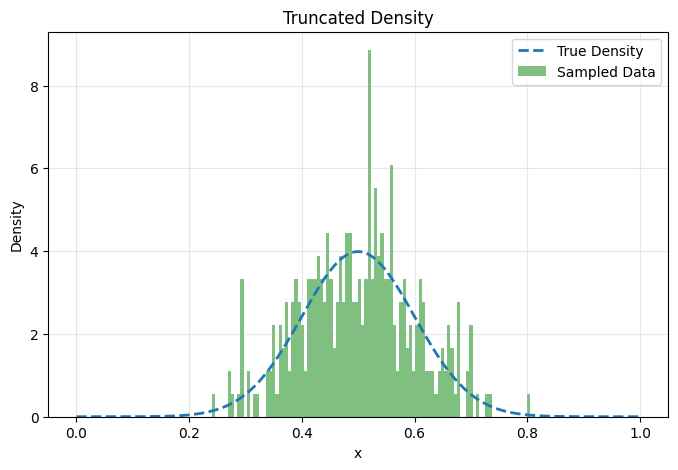

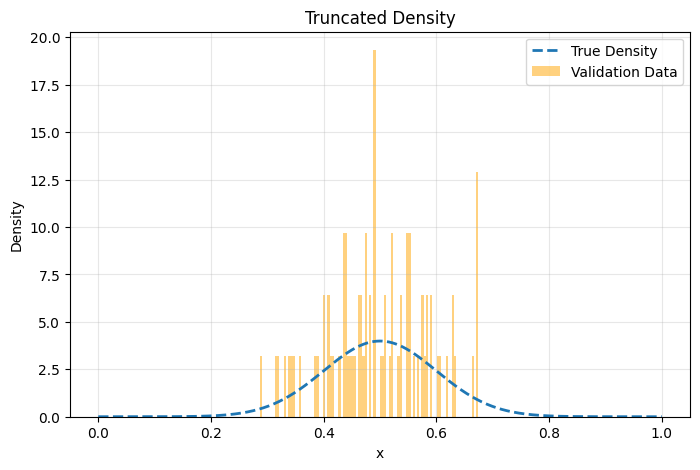

In [3]:
data_all = pd.DataFrame({
    'W1': np.concatenate([
        sampler.generate_samples(n_samples)
    ])
})

# cut data into training and validation sets
data = data_all[:4 * n_samples // 5]
data_val = data_all[4 * n_samples // 5:]

# plot the true density overlaid with training data histogram
plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(np.linspace(0, 1, 1000)),
    title="Truncated Density",
    method_label="True Density",
    hist_data=data["W1"],
    hist_bins=100,
    hist_alpha=0.5,
    hist_label="Sampled Data",
    hist_color="green",
    show=True
)

# plot the true density overlaid with validation data histogram
plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(np.linspace(0, 1, 1000)),
    title="Truncated Density",
    method_label="True Density",
    hist_data=data_val["W1"],
    hist_bins=100,
    hist_alpha=0.5,
    hist_label="Validation Data",
    hist_color="orange",
    show=True
)

In [4]:
tuner = OptunaHyperparameterTuner('CVXPYEstimator', data, cv_folds=5, metric='sll', silent=True, show_progress=True)
res = tuner.optimize(n_trials=100, show_progress=False)
print('Best params:', res['best_params']); print('Best CV:', res['best_metric_value'])

best_est = tuner.fit_best_model()

estimator_params = {
    'basis_order': getattr(best_est, 'basis_order', 0),
    'norm_constraint': getattr(best_est, 'norm_constraint', 1e3),
}

print('Estimator params:', estimator_params)
estimator = CVXPYEstimator(**estimator_params)

Optimizing CVXPYEstimator: 100%|██████████| 100/100 [02:55<00:00,  1.76s/trial, Best SLL: 0.8751]

Best params: {'basis_order': 2, 'norm_constraint': 72.12371165406199}
Best CV: 0.8751084552256361
Estimator params: {'basis_order': 2, 'norm_constraint': 72.12371165406199}


Fitting CVXPYEstimator ...
Finished fitting CVXPYEstimator ...


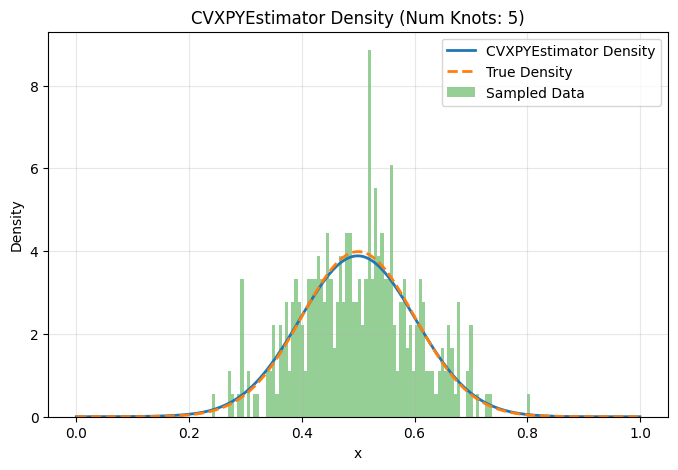

In [5]:
estimator_setup = {
    "estimator": estimator.__class__.__name__,
    "estimator_params": estimator_params,
}

fit_params = {
    'data': data,
}

# fitting the estimator
print(f"Fitting {estimator.__class__.__name__} ...")
estimator.fit(**fit_params)
print(f"Finished fitting {estimator.__class__.__name__} ...")

# Get results
grid_points, estimated_density = estimator.get_density()
estimation_results = estimator.get_results()

# Compute true density vs estimated density overlaid with training histogram
plot_density(
    grid_points=grid_points,
    true_density=sampler.compute_density(grid_points),
    estimated_density=estimated_density,
    title=f"{estimator.__class__.__name__} Density (Num Knots: {estimation_results.get('n_selected_knots', 'N/A')})",
    method_label=f"{estimator.__class__.__name__} Density",
    hist_data=data["W1"],
    hist_bins=100,
    hist_alpha=0.5,
    hist_label="Sampled Data",
    show=True
)

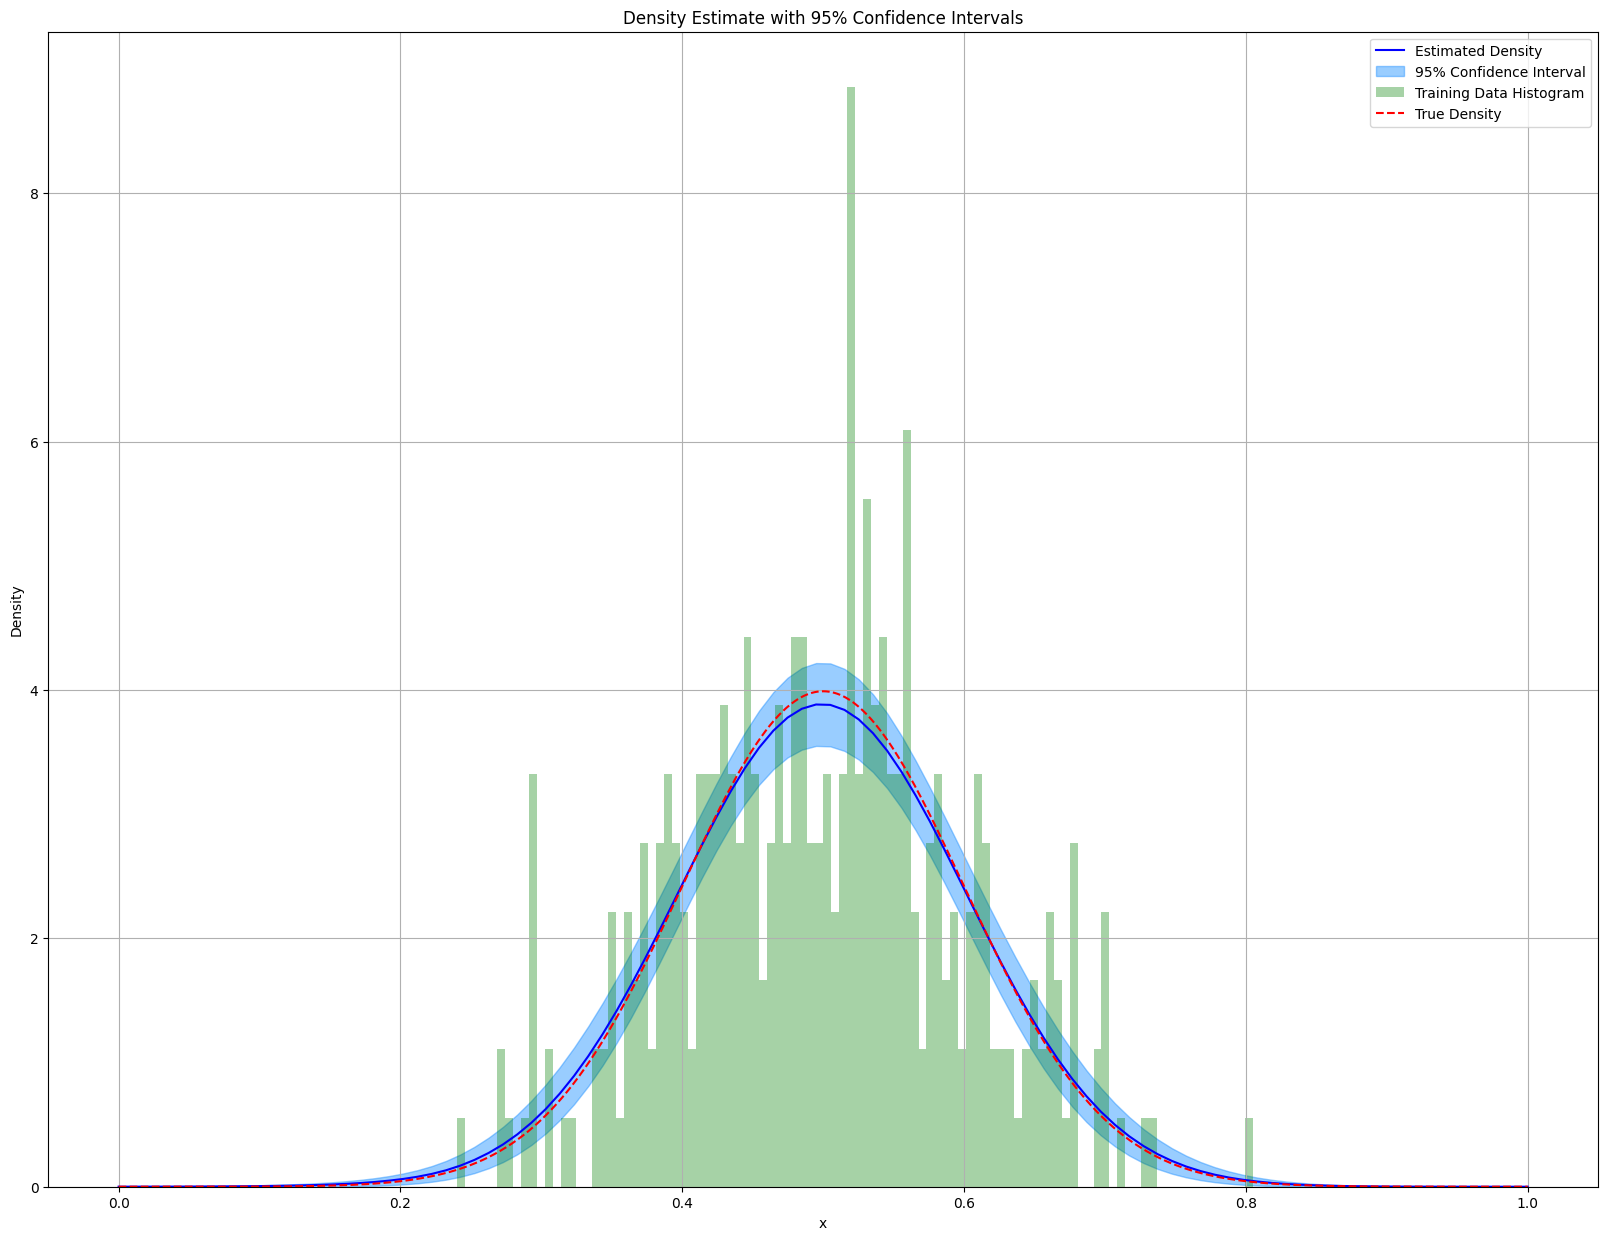

In [6]:
from src.haldensity.density_variance.density_variance import (
    estimate_covariance_beta,
    density_confidence_interval
)

basis_order = estimator_setup["estimator_params"]["basis_order"]

# (This will use all observations in full data.)
cov_beta = estimate_covariance_beta(data=data, estimation_results=estimation_results, basis_order=basis_order, ridge_param=1e-5)

# Define evaluation points (for example, 100 equally spaced points between 0 and 1):
x_vals = np.linspace(0, 1, 100)

# Compute confidence intervals for the density estimates:
ci_df = density_confidence_interval(x_values=x_vals, estimation_results=estimation_results, cov_beta=cov_beta, basis_order=basis_order, alpha=0.05)

# Plot the results:
plt.figure(figsize=(20,15))
plt.plot(ci_df['x'], ci_df['density'], label='Estimated Density', color='blue')
plt.fill_between(ci_df['x'], ci_df['lower'], ci_df['upper'], color='dodgerblue', alpha=0.45,
                 label='95% Confidence Interval')
plt.hist(data['W1'], bins=100, density=True, alpha=0.35, label='Training Data Histogram', color='green')
plt.plot(np.linspace(0, 1, 1001), sampler.compute_density(np.linspace(0, 1, 1001)), label='True Density', color='red', linestyle='--')
plt.legend()    
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density Estimate with 95% Confidence Intervals')
plt.legend()
plt.grid()
plt.show()